In [1]:
# ==========================================================
# MINI PROJECT 4
# HAWKES PROCESS OF ORDER BOOK IMBALANCE EVENTS
# PART 1
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from google.colab import files

# ==========================================================
# STEP 1 : Upload Dataset
# ==========================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

depth = pd.read_csv(filename)

# ==========================================================
# STEP 2 : Data Preparation
# ==========================================================

depth["timestamp"] = pd.to_datetime(depth["timestamp"])

depth = depth.sort_values("timestamp").reset_index(drop=True)

# Remove crossed quotes

depth = depth[
    depth["best_ask"] >= depth["best_bid"]
].copy()

depth.reset_index(drop=True, inplace=True)

print("Rows after cleaning :", len(depth))

# ==========================================================
# STEP 3 : Compute Order Book Imbalance
# ==========================================================

depth["order_book_imbalance"] = (

    depth["bid_volume_1"] -

    depth["ask_volume_1"]

) / (

    depth["bid_volume_1"] +

    depth["ask_volume_1"]

)

print(depth["order_book_imbalance"].describe())

# ==========================================================
# STEP 4 : Define Extreme Imbalance Event
# ==========================================================

threshold = 0.60

depth["imbalance_event"] = (

    np.abs(depth["order_book_imbalance"]) >

    threshold

).astype(int)

events = depth[
    depth["imbalance_event"] == 1
].copy()

print("Number of Imbalance Events :", len(events))

# ==========================================================
# STEP 5 : Event Times
# ==========================================================

event_times = (

    events["timestamp"] -

    depth["timestamp"].iloc[0]

).dt.total_seconds().values

T = event_times[-1]

print("Observation Time :", T)

# ==========================================================
# STEP 6 : Recursive Hawkes Log-Likelihood
# ==========================================================

def negative_log_likelihood(params):

    mu, alpha, beta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:

        return np.inf

    n = len(event_times)

    R = np.zeros(n)

    for i in range(1, n):

        dt = event_times[i] - event_times[i-1]

        R[i] = np.exp(-beta * dt) * (1 + R[i-1])

    intensity = mu + alpha * R

    if np.any(intensity <= 0):

        return np.inf

    loglik = np.sum(np.log(intensity))

    compensator = (

        mu * T +

        (alpha / beta) *

        np.sum(

            1 -

            np.exp(

                -beta *

                (T - event_times)

            )

        )

    )

    return -(loglik - compensator)

# ==========================================================
# STEP 7 : Estimate Parameters
# ==========================================================

result = minimize(

    negative_log_likelihood,

    x0=[0.10,0.20,1.00],

    method="L-BFGS-B",

    bounds=[

        (1e-6,None),

        (1e-6,None),

        (1e-6,None)

    ]

)

mu_hat, alpha_hat, beta_hat = result.x

print("\nOptimization Completed")

print("--------------------------")

print("Success :", result.success)

print("Message :", result.message)

print()

print("Estimated Parameters")

print("--------------------------")

print("μ :", mu_hat)

print("α :", alpha_hat)

print("β :", beta_hat)

Saving BTCUSDT_Depth_1Hour.csv to BTCUSDT_Depth_1Hour.csv
Rows after cleaning : 31422


KeyError: 'bid_volume_1'

In [2]:
print(depth.columns.tolist())

['timestamp', 'best_bid', 'best_bid_qty', 'best_ask', 'best_ask_qty', 'bid_price_1', 'bid_qty_1', 'ask_price_1', 'ask_qty_1', 'bid_price_2', 'bid_qty_2', 'ask_price_2', 'ask_qty_2', 'bid_price_3', 'bid_qty_3', 'ask_price_3', 'ask_qty_3', 'bid_price_4', 'bid_qty_4', 'ask_price_4', 'ask_qty_4', 'bid_price_5', 'bid_qty_5', 'ask_price_5', 'ask_qty_5', 'bid_price_6', 'bid_qty_6', 'ask_price_6', 'ask_qty_6', 'bid_price_7', 'bid_qty_7', 'ask_price_7', 'ask_qty_7', 'bid_price_8', 'bid_qty_8', 'ask_price_8', 'ask_qty_8', 'bid_price_9', 'bid_qty_9', 'ask_price_9', 'ask_qty_9', 'bid_price_10', 'bid_qty_10', 'ask_price_10', 'ask_qty_10']


In [3]:
# ==========================================================
# STEP 3 : Compute Level-10 Order Book Imbalance
# ==========================================================

# Sum Bid Quantities (Levels 1-10)
bid_columns = [
    "bid_qty_1","bid_qty_2","bid_qty_3","bid_qty_4","bid_qty_5",
    "bid_qty_6","bid_qty_7","bid_qty_8","bid_qty_9","bid_qty_10"
]

# Sum Ask Quantities (Levels 1-10)
ask_columns = [
    "ask_qty_1","ask_qty_2","ask_qty_3","ask_qty_4","ask_qty_5",
    "ask_qty_6","ask_qty_7","ask_qty_8","ask_qty_9","ask_qty_10"
]

depth["total_bid_qty"] = depth[bid_columns].sum(axis=1)

depth["total_ask_qty"] = depth[ask_columns].sum(axis=1)

depth["order_book_imbalance"] = (

    depth["total_bid_qty"] -
    depth["total_ask_qty"]

) / (

    depth["total_bid_qty"] +
    depth["total_ask_qty"]

)

print("="*60)
print("LEVEL-10 ORDER BOOK IMBALANCE")
print("="*60)

print(depth["order_book_imbalance"].describe())

LEVEL-10 ORDER BOOK IMBALANCE
count    31398.000000
mean         0.028419
std          0.745274
min         -1.000000
25%         -0.734283
50%          0.020047
75%          0.800092
max          1.000000
Name: order_book_imbalance, dtype: float64


In [4]:
# ==========================================================
# STEP 4 : Extreme Imbalance Events
# ==========================================================

threshold = depth["order_book_imbalance"].quantile(0.95)

print("Threshold :", threshold)

depth["imbalance_event"] = (
    np.abs(depth["order_book_imbalance"]) > threshold
).astype(int)

events = depth[
    depth["imbalance_event"] == 1
].copy()

print("Number of Events :", len(events))

Threshold : 0.9971966343784575
Number of Events : 3027


In [5]:
# ==========================================================
# STEP 5 : Event Times
# ==========================================================

event_times = (
    events["timestamp"] -
    depth["timestamp"].iloc[0]
).dt.total_seconds().values

T = event_times[-1]

print("="*60)
print("Number of Events :", len(event_times))
print("Observation Time :", T)

# ==========================================================
# STEP 6 : Recursive Hawkes Log-Likelihood
# ==========================================================

def negative_log_likelihood(params):

    mu, alpha, beta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    n = len(event_times)

    R = np.zeros(n)

    for i in range(1, n):

        dt = event_times[i] - event_times[i-1]

        R[i] = np.exp(-beta * dt) * (1 + R[i-1])

    intensity = mu + alpha * R

    if np.any(intensity <= 0):
        return np.inf

    loglik = np.sum(np.log(intensity))

    compensator = (
        mu * T +
        (alpha / beta) *
        np.sum(
            1 -
            np.exp(
                -beta * (T - event_times)
            )
        )
    )

    return -(loglik - compensator)

# ==========================================================
# STEP 7 : Estimate Parameters
# ==========================================================

result = minimize(

    negative_log_likelihood,

    x0=[0.10, 0.20, 1.00],

    method="L-BFGS-B",

    bounds=[
        (1e-6, None),
        (1e-6, None),
        (1e-6, None)
    ]

)

mu_hat, alpha_hat, beta_hat = result.x

print("\n==============================")
print("Optimization Results")
print("==============================")

print("Success :", result.success)
print("Message :", result.message)

print("\nEstimated Parameters")
print("------------------------------")
print(f"μ (Baseline)   : {mu_hat:.6f}")
print(f"α (Excitation) : {alpha_hat:.6f}")
print(f"β (Decay)      : {beta_hat:.6f}")

Number of Events : 3027
Observation Time : 3597.976

Optimization Results
Success : True
Message : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Estimated Parameters
------------------------------
μ (Baseline)   : 0.347372
α (Excitation) : 0.164508
β (Decay)      : 0.279874


Hawkes intensity computed successfully.
Poisson Intensity : 0.8413063344502576
             Metric        Value
0  Number of Events  3027.000000
1  Observation Time  3597.976000
2       Estimated μ     0.347372
3       Estimated α     0.164508
4       Estimated β     0.279874
5         Poisson λ     0.841306


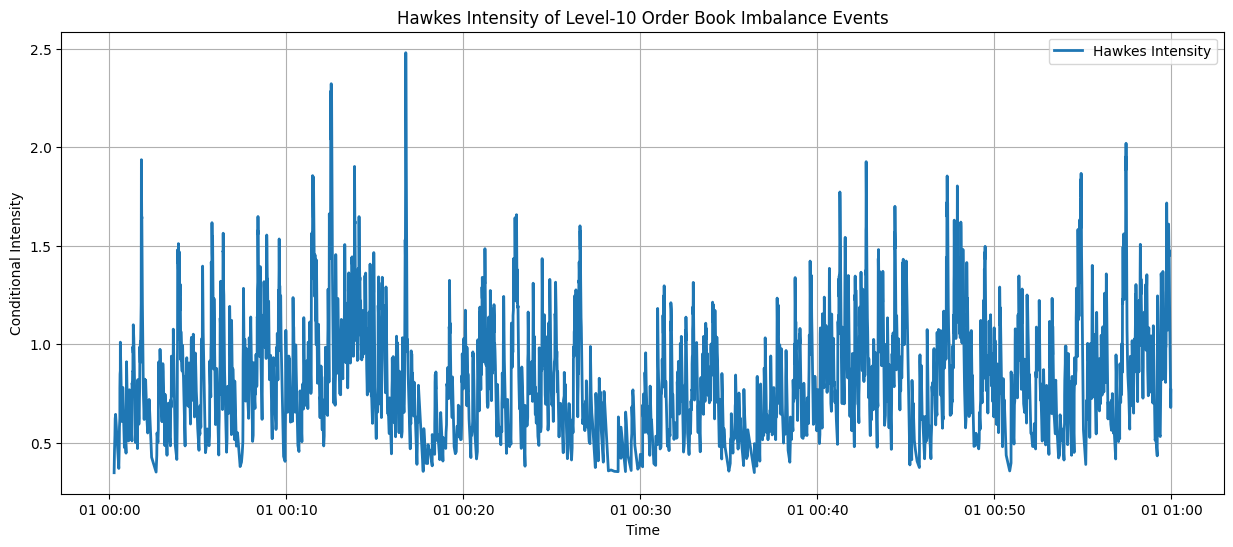

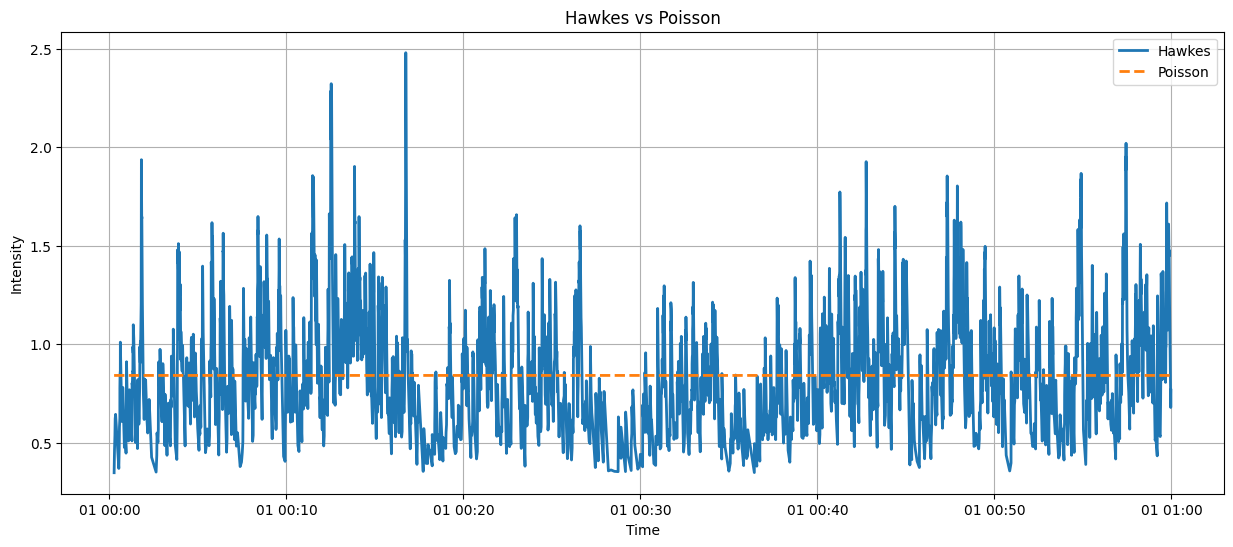

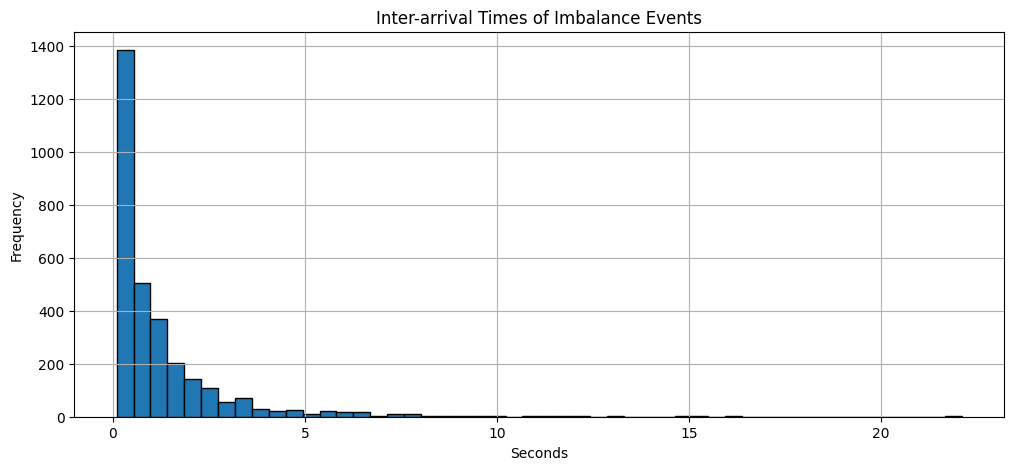


MODEL COMPARISON
     Model  LogLikelihood          AIC          BIC
0  Poisson   -3550.063890  7102.127780  7108.143107
1   Hawkes   -3376.234625  6758.469249  6776.515231

Likelihood Ratio Statistic : 347.6585307710893

INTERPRETATION
Moderate self-excitation detected in Level-10 order book imbalance events.
✓ Hawkes model outperforms the Poisson model based on AIC.
✓ Hawkes model outperforms the Poisson model based on BIC.
✓ Likelihood Ratio Test supports the Hawkes model.

Mini Project 4 Completed Successfully.


In [6]:
# ==========================================================
# PART 2
# HAWKES INTENSITY
# ==========================================================

n = len(event_times)

R = np.zeros(n)

hawkes_intensity = np.zeros(n)

hawkes_intensity[0] = mu_hat

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

    hawkes_intensity[i] = mu_hat + alpha_hat * R[i]

events["hawkes_intensity"] = hawkes_intensity

print("Hawkes intensity computed successfully.")

# ==========================================================
# POISSON MODEL
# ==========================================================

poisson_lambda = len(event_times) / T

events["poisson_intensity"] = poisson_lambda

print("Poisson Intensity :", poisson_lambda)

# ==========================================================
# SUMMARY TABLE
# ==========================================================

summary = pd.DataFrame({

    "Metric":[

        "Number of Events",

        "Observation Time",

        "Estimated μ",

        "Estimated α",

        "Estimated β",

        "Poisson λ"

    ],

    "Value":[

        len(event_times),

        T,

        mu_hat,

        alpha_hat,

        beta_hat,

        poisson_lambda

    ]

})

print(summary)

# ==========================================================
# HAWKES INTENSITY PLOT
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    events["timestamp"],
    events["hawkes_intensity"],
    linewidth=2,
    label="Hawkes Intensity"
)

plt.title("Hawkes Intensity of Level-10 Order Book Imbalance Events")

plt.xlabel("Time")

plt.ylabel("Conditional Intensity")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# HAWKES VS POISSON
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    events["timestamp"],
    events["hawkes_intensity"],
    linewidth=2,
    label="Hawkes"
)

plt.plot(
    events["timestamp"],
    events["poisson_intensity"],
    "--",
    linewidth=2,
    label="Poisson"
)

plt.title("Hawkes vs Poisson")

plt.xlabel("Time")

plt.ylabel("Intensity")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# INTER-ARRIVAL DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,5))

plt.hist(
    np.diff(event_times),
    bins=50,
    edgecolor="black"
)

plt.title("Inter-arrival Times of Imbalance Events")

plt.xlabel("Seconds")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

R = np.zeros(n)

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

hawkes_intensity = mu_hat + alpha_hat * R

hawkes_loglik = np.sum(np.log(hawkes_intensity))

hawkes_loglik -= (

    mu_hat * T +

    (alpha_hat / beta_hat) *

    np.sum(

        1 -

        np.exp(

            -beta_hat *

            (T - event_times)

        )

    )

)

lambda_hat = len(event_times) / T

poisson_loglik = (

    len(event_times) *

    np.log(lambda_hat)

    -

    lambda_hat * T

)

hawkes_aic = 2 * 3 - 2 * hawkes_loglik

poisson_aic = 2 * 1 - 2 * poisson_loglik

hawkes_bic = np.log(len(event_times)) * 3 - 2 * hawkes_loglik

poisson_bic = np.log(len(event_times)) * 1 - 2 * poisson_loglik

lrt = 2 * (hawkes_loglik - poisson_loglik)

comparison = pd.DataFrame({

    "Model":[
        "Poisson",
        "Hawkes"
    ],

    "LogLikelihood":[
        poisson_loglik,
        hawkes_loglik
    ],

    "AIC":[
        poisson_aic,
        hawkes_aic
    ],

    "BIC":[
        poisson_bic,
        hawkes_bic
    ]

})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)

print("\nLikelihood Ratio Statistic :", lrt)

# ==========================================================
# INTERPRETATION
# ==========================================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

if alpha_hat > 0.10:
    print("Moderate self-excitation detected in Level-10 order book imbalance events.")
else:
    print("Weak self-excitation detected.")

if hawkes_aic < poisson_aic:
    print("✓ Hawkes model outperforms the Poisson model based on AIC.")
else:
    print("✓ Poisson model outperforms the Hawkes model based on AIC.")

if hawkes_bic < poisson_bic:
    print("✓ Hawkes model outperforms the Poisson model based on BIC.")
else:
    print("✓ Poisson model outperforms the Hawkes model based on BIC.")

if lrt > 3.84:
    print("✓ Likelihood Ratio Test supports the Hawkes model.")
else:
    print("✓ Likelihood Ratio Test does not support the Hawkes model.")

print("\nMini Project 4 Completed Successfully.")